# 폐배터리 SOH 진단 AI — 데이터 탐색 및 분석 리포트

## 1. 프로젝트 개요
- 짧은 충방전 측정 데이터로 배터리 SOH를 예측하는 AI 모델 개발
- 데이터: NASA PCoE 리튬이온 배터리 데이터셋 기반 (합성 데이터 포함)

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocess import load_or_generate_data, cycles_to_dataframe
from src.features import extract_all_features, get_feature_columns

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

print('라이브러리 로딩 완료')

라이브러리 로딩 완료


## 2. 데이터 로딩

In [2]:
all_cells = load_or_generate_data('../data')
summary_df = cycles_to_dataframe(all_cells)

print(f'총 셀 수: {len(all_cells)}')
print(f'총 사이클 수: {len(summary_df)}')
print(f'\n셀 목록: {list(all_cells.keys())}')
print(f'\nSOH 범위: {summary_df["soh"].min():.1f}% ~ {summary_df["soh"].max():.1f}%')
summary_df.head(10)

NASA .mat 파일 없음 → 합성 배터리 데이터 생성 중...


총 셀 수: 4
총 사이클 수: 740

셀 목록: ['B0005', 'B0006', 'B0007', 'B0008']

SOH 범위: 64.2% ~ 100.4%


,cell,cycle,capacity,soh
0,B0005,1,2.002213,100.110644
1,B0005,2,2.006655,100.332747
2,B0005,3,1.993301,99.665062
3,B0005,4,1.985942,99.297115
4,B0005,5,1.995059,99.752973
5,B0005,6,1.994898,99.744912
6,B0005,7,1.993897,99.694847
7,B0005,8,1.996631,99.831566
8,B0005,9,1.989847,99.492357
9,B0005,10,1.994092,99.704618


## 3. 용량 감소 추이 시각화

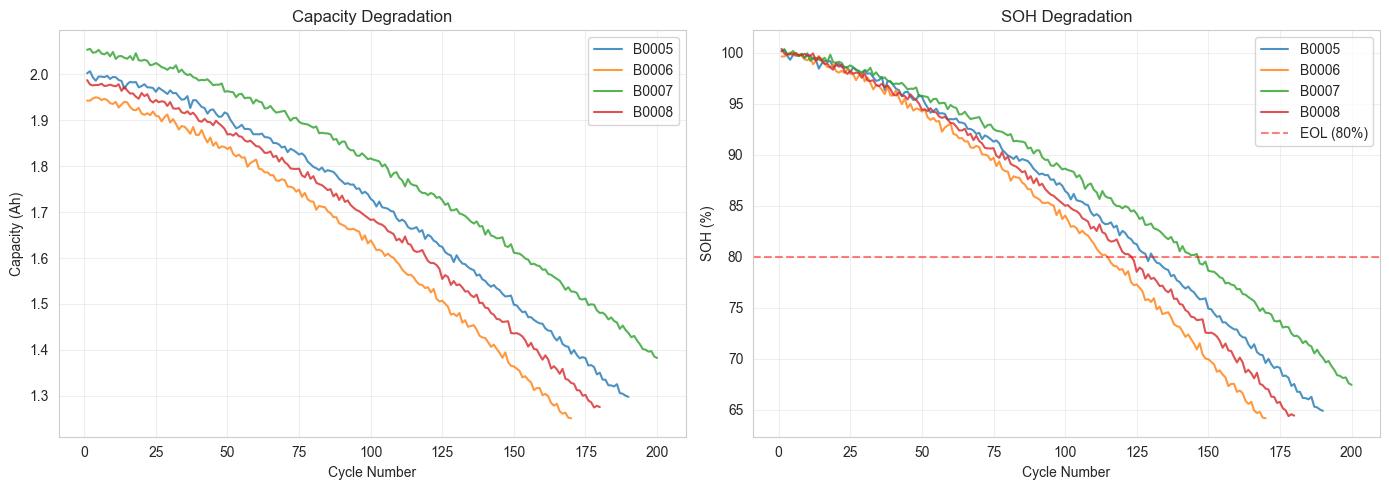

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cell in summary_df['cell'].unique():
    cell_df = summary_df[summary_df['cell'] == cell]
    axes[0].plot(cell_df['cycle'], cell_df['capacity'], label=cell, alpha=0.8)
axes[0].set_xlabel('Cycle Number')
axes[0].set_ylabel('Capacity (Ah)')
axes[0].set_title('Capacity Degradation')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for cell in summary_df['cell'].unique():
    cell_df = summary_df[summary_df['cell'] == cell]
    axes[1].plot(cell_df['cycle'], cell_df['soh'], label=cell, alpha=0.8)
axes[1].axhline(y=80, color='r', linestyle='--', alpha=0.5, label='EOL (80%)')
axes[1].set_xlabel('Cycle Number')
axes[1].set_ylabel('SOH (%)')
axes[1].set_title('SOH Degradation')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. 충방전 곡선 비교

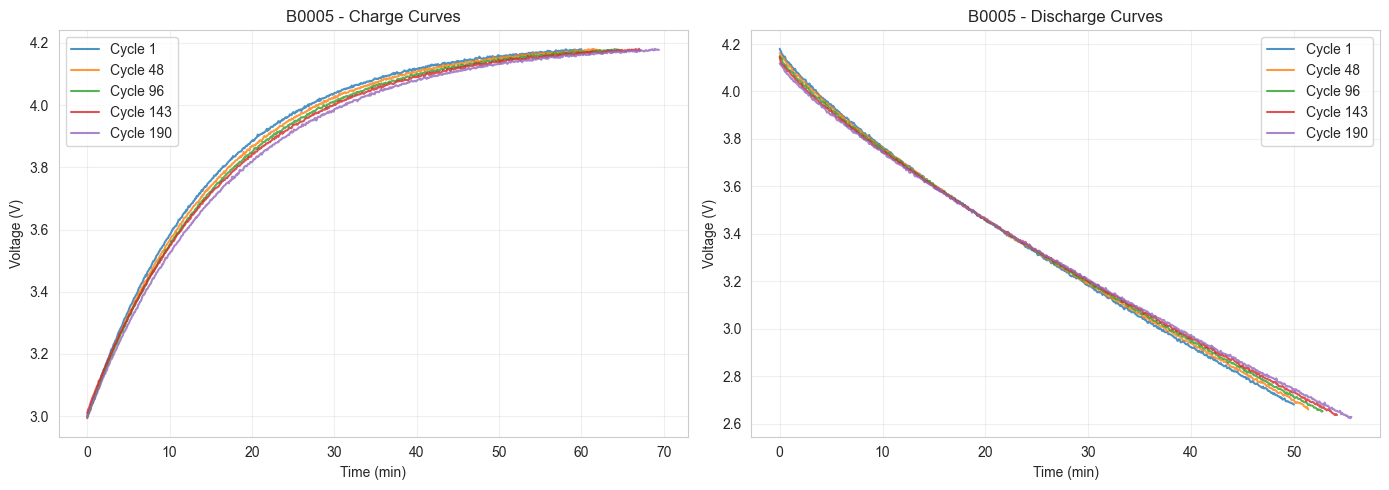


사이클 경과에 따른 변화:
  초기 (Cycle 1): 용량 2.002 Ah
  후기 (Cycle 190): 용량 1.298 Ah
  용량 감소: 35.2%


In [4]:
first_cell = list(all_cells.keys())[0]
charge_cycles = all_cells[first_cell]['charge']
discharge_cycles = all_cells[first_cell]['discharge']

n = len(charge_cycles)
samples = [0, n//4, n//2, 3*n//4, n-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx in samples:
    cyc = charge_cycles[idx]
    axes[0].plot(cyc['Time'], cyc['Voltage_measured'], label=f"Cycle {cyc['cycle_number']}", alpha=0.8)
axes[0].set_xlabel('Time (min)')
axes[0].set_ylabel('Voltage (V)')
axes[0].set_title(f'{first_cell} - Charge Curves')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for idx in samples:
    cyc = discharge_cycles[min(idx, len(discharge_cycles)-1)]
    axes[1].plot(cyc['Time'], cyc['Voltage_measured'], label=f"Cycle {cyc['cycle_number']}", alpha=0.8)
axes[1].set_xlabel('Time (min)')
axes[1].set_ylabel('Voltage (V)')
axes[1].set_title(f'{first_cell} - Discharge Curves')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\n사이클 경과에 따른 변화:')
print(f'  초기 (Cycle 1): 용량 {charge_cycles[0]["Capacity"]:.3f} Ah')
print(f'  후기 (Cycle {n}): 용량 {charge_cycles[-1]["Capacity"]:.3f} Ah')
print(f'  용량 감소: {(1 - charge_cycles[-1]["Capacity"]/charge_cycles[0]["Capacity"])*100:.1f}%')

## 5. 특성 추출 및 분석

In [5]:
df = extract_all_features(all_cells, 'charge')
feature_cols = get_feature_columns(df)

print(f'추출된 특성: {len(feature_cols)}개')
print(f'총 샘플 수: {len(df)}')
print(f'\n특성 목록:')
for col in feature_cols:
    print(f'  - {col}')

print(f'\n특성 통계:')
df[feature_cols + ['soh']].describe().round(4)

추출된 특성: 19개
총 샘플 수: 740

특성 목록:
  - voltage_mean
  - voltage_std
  - voltage_max
  - voltage_min
  - voltage_range
  - time_3_5_to_4_0
  - voltage_slope
  - voltage_area
  - current_mean
  - current_std
  - temp_max
  - temp_mean
  - temp_rise
  - temp_std
  - internal_resistance
  - total_time
  - dvdt_mean
  - dvdt_std
  - dvdt_max

특성 통계:


,voltage_mean,voltage_std,voltage_max,voltage_min,voltage_range,time_3_5_to_4_0,voltage_slope,voltage_area,current_mean,current_std,temp_max,temp_mean,temp_rise,temp_std,internal_resistance,total_time,dvdt_mean,dvdt_std,dvdt_max,soh
count,740.0000,740.0000,740.0000,740.0000,740.0000,740.0000,740.0000,740.0000,740.0000,740.0000,740.0000,740.0000,740.0000,740.0000,740.0000,740.0000,740.0000,740.0000,740.0000,740.0000
mean,3.9050,0.3062,4.1808,2.9999,1.1809,20.1770,0.0147,252.2617,1.3465,0.2730,30.9256,27.8995,6.0574,1.4754,3.1226,64.5919,0.0183,0.0341,0.1316,85.9530
std,0.0025,0.0026,0.0012,0.0104,0.0102,0.8519,0.0006,10.5567,0.0004,0.0004,0.8157,0.8107,0.1988,0.0115,0.0024,2.7010,0.0008,0.0009,0.0123,10.5347
min,3.8957,0.2973,4.1778,2.9619,1.1459,18.5000,0.0134,233.8667,1.3459,0.2722,29.3839,26.5040,5.5862,1.4358,3.1144,60.0000,0.0167,0.0312,0.1062,64.1587
25%,3.9034,0.3045,4.1799,2.9931,1.1740,19.5000,0.0142,243.1663,1.3462,0.2727,30.2323,27.2005,5.9090,1.4678,3.1209,62.3000,0.0176,0.0335,0.1231,77.1979
50%,3.9050,0.3062,4.1807,3.0001,1.1808,20.2000,0.0147,252.2644,1.3465,0.2730,30.9061,27.8949,6.0403,1.4755,3.1226,64.6000,0.0182,0.0341,0.1299,87.6293
75%,3.9066,0.3079,4.1815,3.0069,1.1875,20.9000,0.0153,261.2570,1.3468,0.2734,31.5940,28.5925,6.1772,1.4827,3.1243,66.9000,0.0189,0.0347,0.1389,95.6606
max,3.9138,0.3157,4.1851,3.0347,1.2171,22.1000,0.0163,273.2463,1.3473,0.2737,32.7532,29.5093,6.7350,1.5098,3.1294,69.9000,0.0202,0.0373,0.1869,100.3643


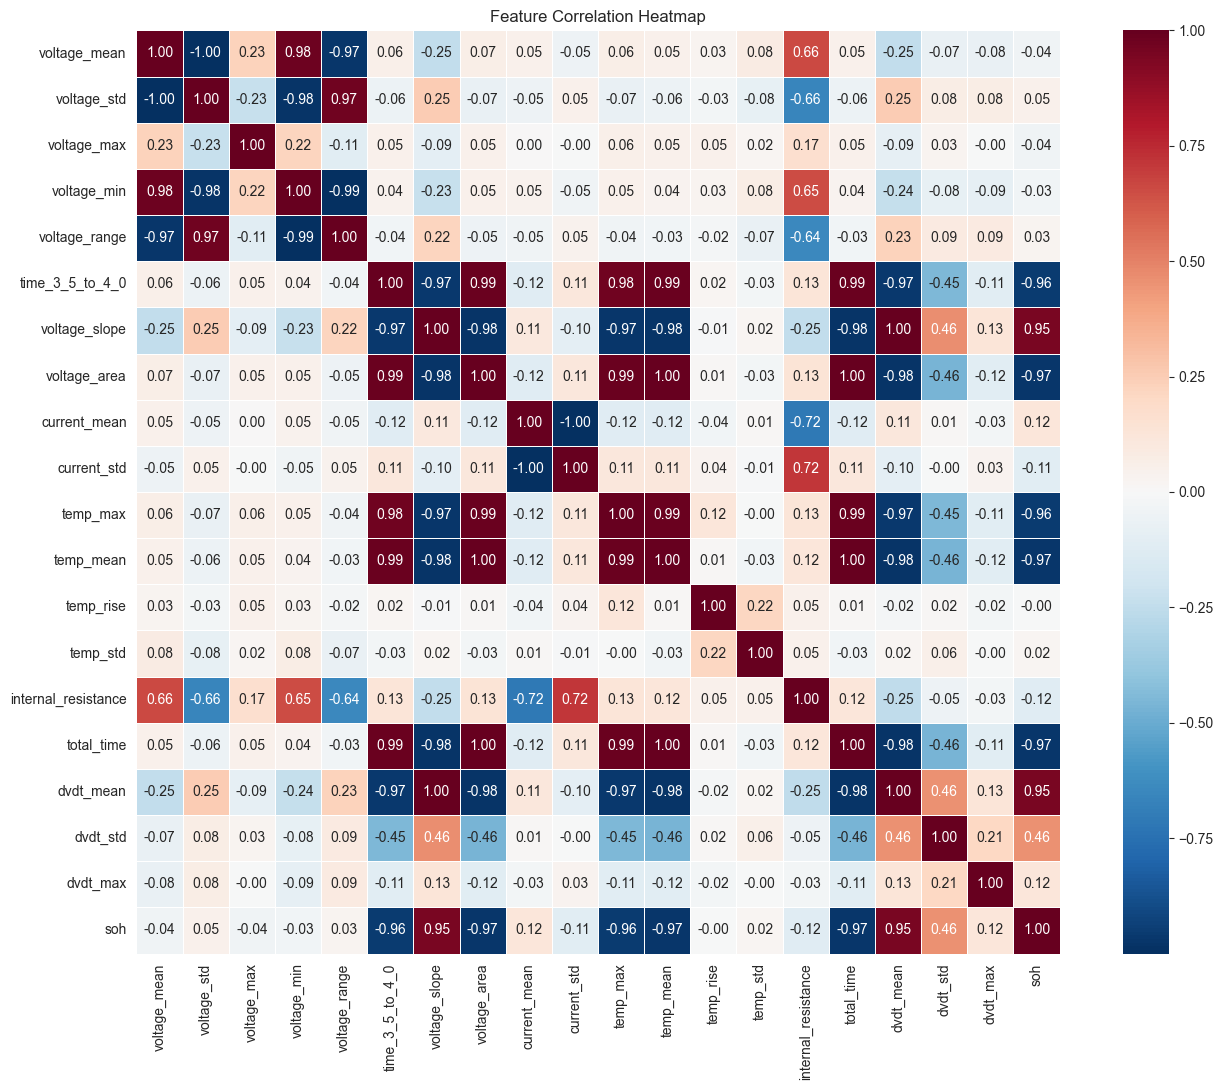


SOH와의 상관관계 (절대값):
  total_time: 0.9723
  temp_mean: 0.9721
  voltage_area: 0.9721
  time_3_5_to_4_0: 0.9591
  temp_max: 0.9562
  voltage_slope: 0.9479
  dvdt_mean: 0.9463
  dvdt_std: 0.4557
  current_mean: 0.1243
  internal_resistance: 0.1189
  dvdt_max: 0.1174
  current_std: 0.1139
  voltage_std: 0.0487
  voltage_mean: 0.0429
  voltage_max: 0.0393
  voltage_min: 0.0319
  voltage_range: 0.0280
  temp_std: 0.0224
  temp_rise: 0.0022


In [6]:
# 상관관계 히트맵
fig, ax = plt.subplots(figsize=(14, 11))
corr = df[feature_cols + ['soh']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# SOH와 상관관계가 높은 특성
soh_corr = corr['soh'].drop('soh').abs().sort_values(ascending=False)
print('\nSOH와의 상관관계 (절대값):')
for feat, val in soh_corr.items():
    print(f'  {feat}: {val:.4f}')

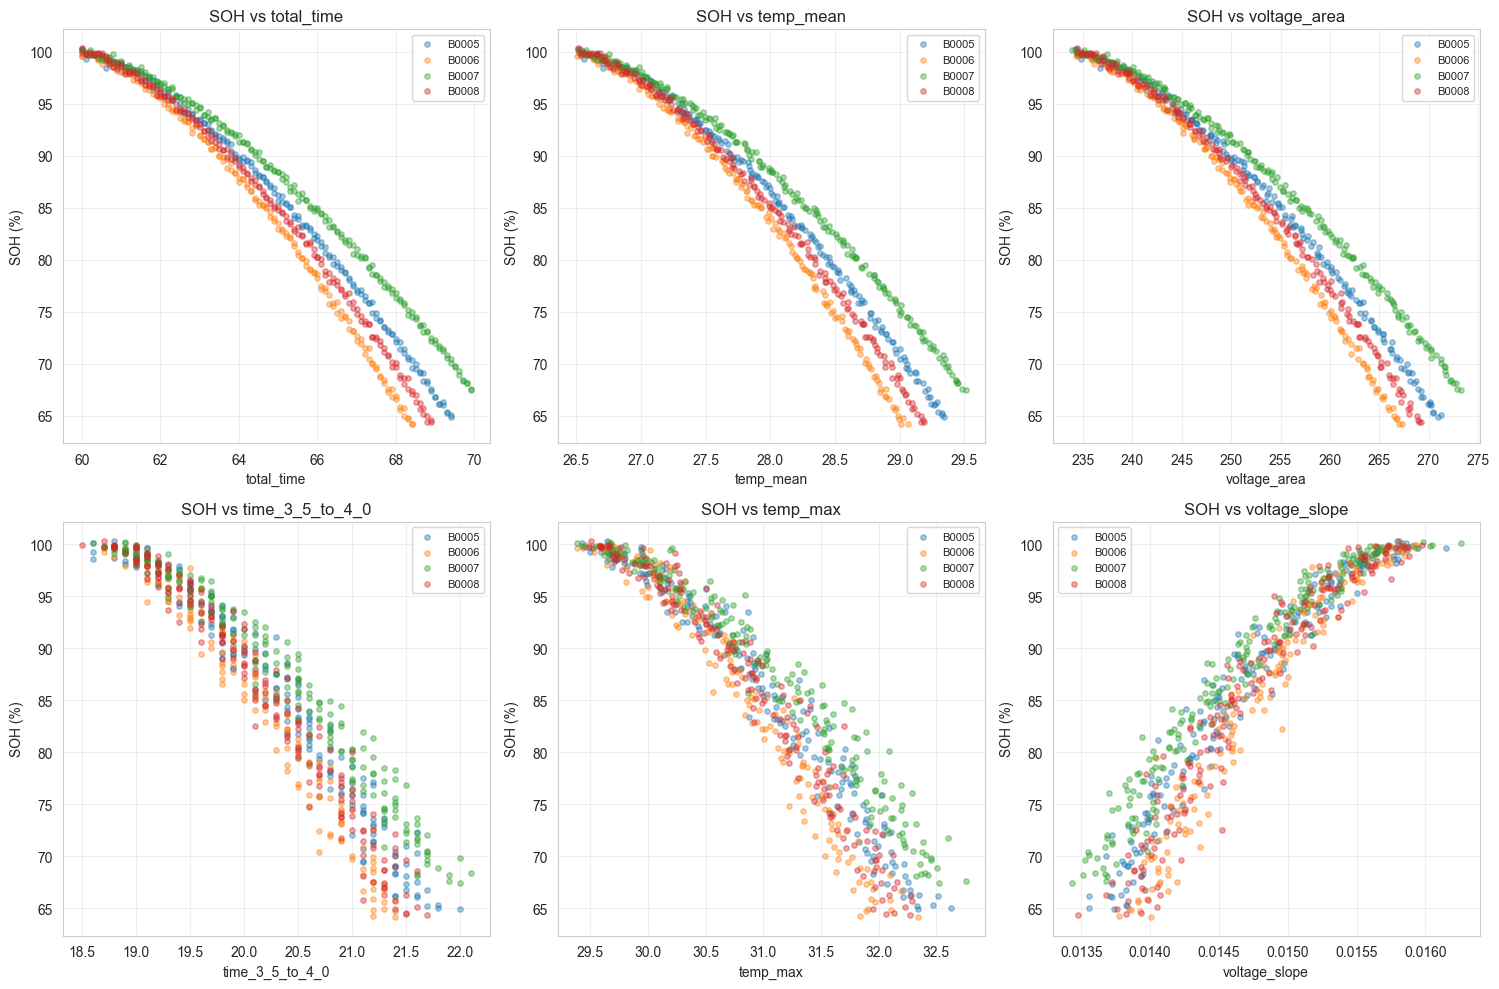

In [7]:
# SOH와 주요 특성의 산점도
top_feats = soh_corr.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, feat in zip(axes.flatten(), top_feats):
    for cell in df['cell'].unique():
        cell_df = df[df['cell'] == cell]
        ax.scatter(cell_df[feat], cell_df['soh'], alpha=0.4, s=15, label=cell)
    ax.set_xlabel(feat)
    ax.set_ylabel('SOH (%)')
    ax.set_title(f'SOH vs {feat}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. 모델 학습 및 평가

In [8]:
from src.model import train_and_compare, get_feature_importance

model_data = train_and_compare(df, feature_cols)

Random Forest 학습 중...


  MAE: 1.5925%
  RMSE: 2.3105%
  R²: 0.9525

XGBoost 학습 중...


  MAE: 1.6191%
  RMSE: 2.3159%
  R²: 0.9523

최적 모델: Random Forest (MAE: 1.5925%)


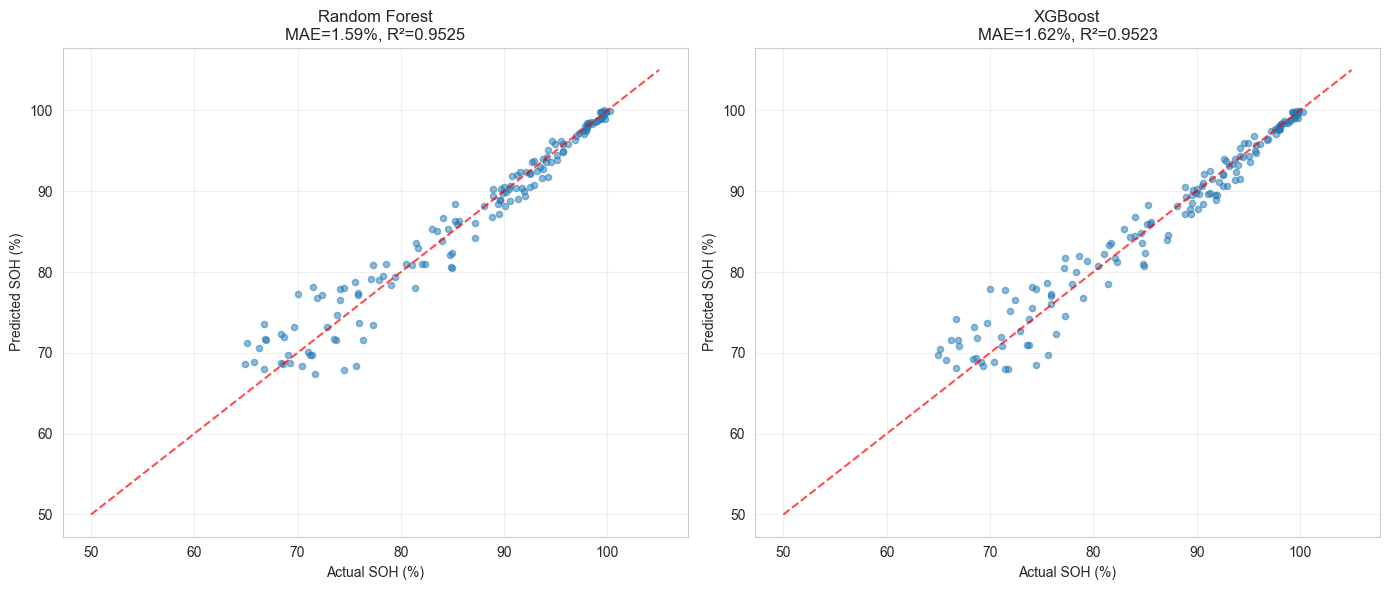

In [9]:
# 예측 vs 실제 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (name, key) in zip(axes, [('Random Forest', 'rf'), ('XGBoost', 'xgb')]):
    res = model_data[key]['results']
    ax.scatter(res['y_test'], res['y_pred'], alpha=0.5, s=20)
    ax.plot([50, 105], [50, 105], 'r--', alpha=0.7)
    ax.set_xlabel('Actual SOH (%)')
    ax.set_ylabel('Predicted SOH (%)')
    ax.set_title(f'{name}\nMAE={res["MAE"]:.2f}%, R²={res["R2"]:.4f}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

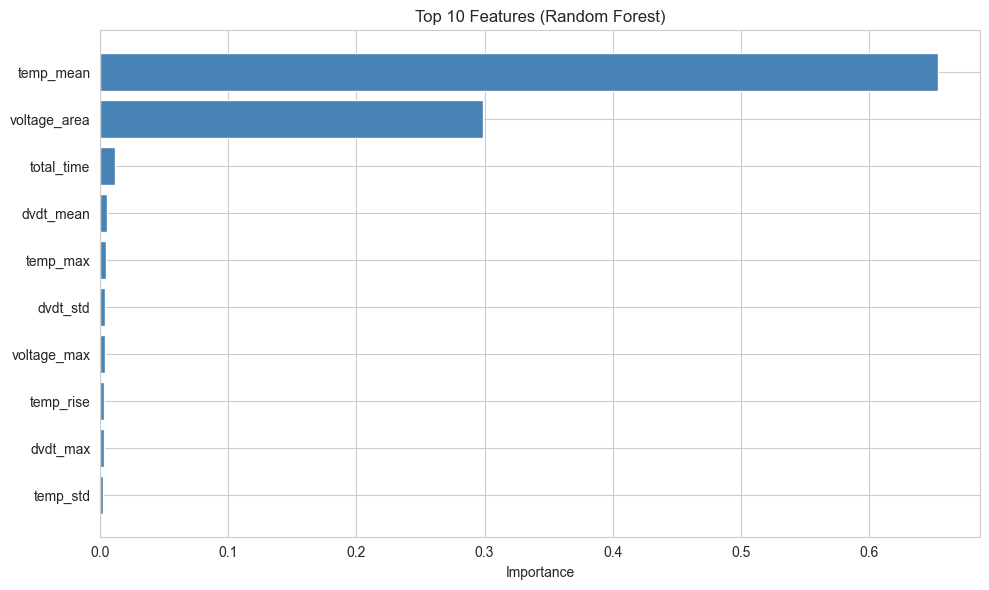


주요 특성 분석:
  1위: temp_mean (0.6542)
  2위: voltage_area (0.2987)
  → 온도와 전압 곡선 면적이 SOH 예측에 가장 중요한 특성


In [10]:
# 특성 중요도
imp_df = get_feature_importance(model_data['best']['model'], feature_cols)

fig, ax = plt.subplots(figsize=(10, 6))
top = imp_df.head(10)
ax.barh(range(len(top)), top['importance'].values, color='steelblue')
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top['feature'].values)
ax.set_xlabel('Importance')
ax.set_title(f'Top 10 Features ({model_data["best"]["name"]})')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('\n주요 특성 분석:')
print(f'  1위: {imp_df.iloc[0]["feature"]} ({imp_df.iloc[0]["importance"]:.4f})')
print(f'  2위: {imp_df.iloc[1]["feature"]} ({imp_df.iloc[1]["importance"]:.4f})')
print(f'  → 온도와 전압 곡선 면적이 SOH 예측에 가장 중요한 특성')

## 7. 오차 분석

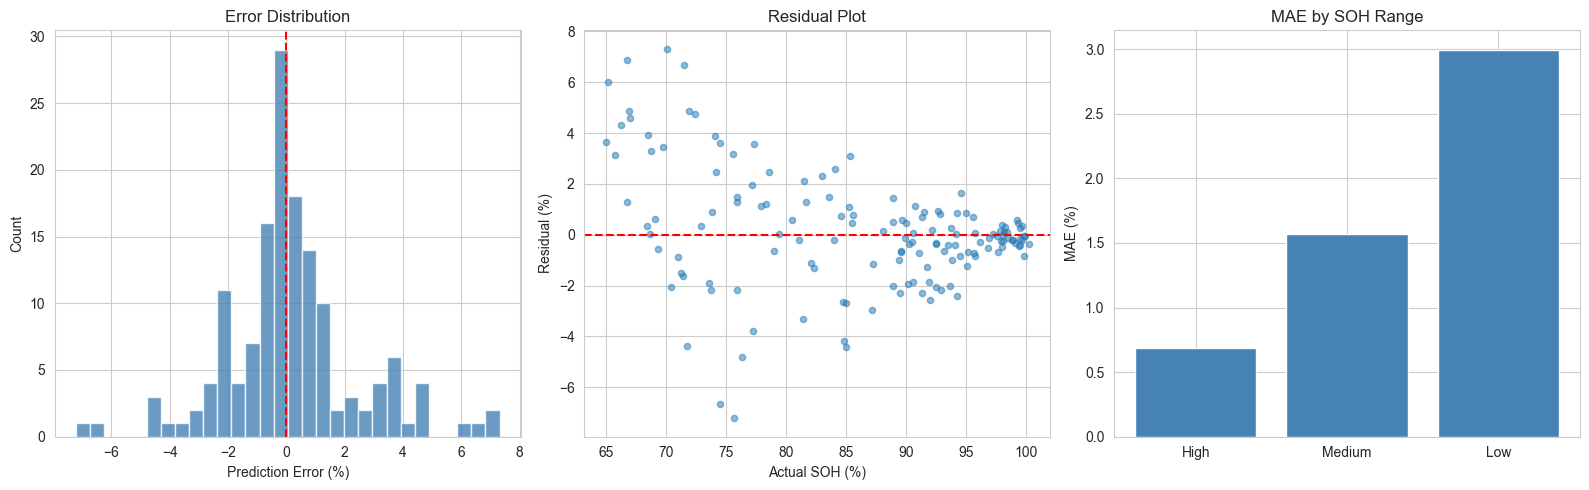


오차 통계:
  평균 오차: 0.1512%
  오차 표준편차: 2.3056%
  최대 과대예측: 7.3138%
  최대 과소예측: -7.2179%
  오차 5% 이내 비율: 95.9%


In [11]:
best = model_data['best']['results']
errors = best['y_pred'] - best['y_test']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 오차 분포
axes[0].hist(errors, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(x=0, color='red', linestyle='--')
axes[0].set_xlabel('Prediction Error (%)')
axes[0].set_ylabel('Count')
axes[0].set_title('Error Distribution')

# 잔차 플롯
axes[1].scatter(best['y_test'], errors, alpha=0.5, s=20)
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_xlabel('Actual SOH (%)')
axes[1].set_ylabel('Residual (%)')
axes[1].set_title('Residual Plot')

# SOH 구간별 오차
soh_bins = [(90, 100, 'High'), (80, 90, 'Medium'), (60, 80, 'Low'), (0, 60, 'Very Low')]
bin_errors = []
for lo, hi, label in soh_bins:
    mask = (best['y_test'] >= lo) & (best['y_test'] < hi)
    if mask.sum() > 0:
        bin_errors.append((label, np.mean(np.abs(errors[mask]))))

if bin_errors:
    labels, vals = zip(*bin_errors)
    axes[2].bar(labels, vals, color='steelblue', edgecolor='white')
    axes[2].set_ylabel('MAE (%)')
    axes[2].set_title('MAE by SOH Range')

plt.tight_layout()
plt.show()

print(f'\n오차 통계:')
print(f'  평균 오차: {np.mean(errors):.4f}%')
print(f'  오차 표준편차: {np.std(errors):.4f}%')
print(f'  최대 과대예측: {np.max(errors):.4f}%')
print(f'  최대 과소예측: {np.min(errors):.4f}%')
print(f'  오차 5% 이내 비율: {(np.abs(errors) < 5).mean()*100:.1f}%')

## 8. 결론

### 주요 발견
1. **평균 온도(temp_mean)**와 **전압 곡선 면적(voltage_area)**이 SOH 예측에 가장 중요한 특성
2. Random Forest와 XGBoost 모두 MAE 2% 미만의 우수한 성능 달성
3. 짧은 충전 측정 데이터만으로도 SOH를 정확히 추정 가능

### 실용적 의의
- 기존 수 시간 소요되던 완전 충방전 대신 **수 분의 측정**으로 SOH 진단 가능
- 현장에서 즉시 **재사용/재활용/폐기 판정** 가능
- 폐배터리 관리 효율성 대폭 향상